In [2]:
# 📄 Visual Error Spotter for Printed Documents

## Objective
# This project analyzes the **visual quality of printed documents** using
# Computer Vision and OCR techniques.

# Instead of reading text content, the system focuses on detecting **visual
# defects** that affect readability and OCR reliability, such as:

# - Skewed text (tilted documents)
# - Poor alignment
# - Printing or scanning defects

# The project uses:
# - OpenCV for image processing
# - OCR bounding boxes for spatial analysis
# - Rule-based metrics for explainability

# This approach avoids deep learning models and focuses on **transparent,
# engineering-based solutions**, making it suitable for academic evaluation.


In [3]:
# !pip install opencv-python

In [4]:
# !pip install numpy

In [5]:
# !pip install matplotlib

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


Load Input Image from File Path


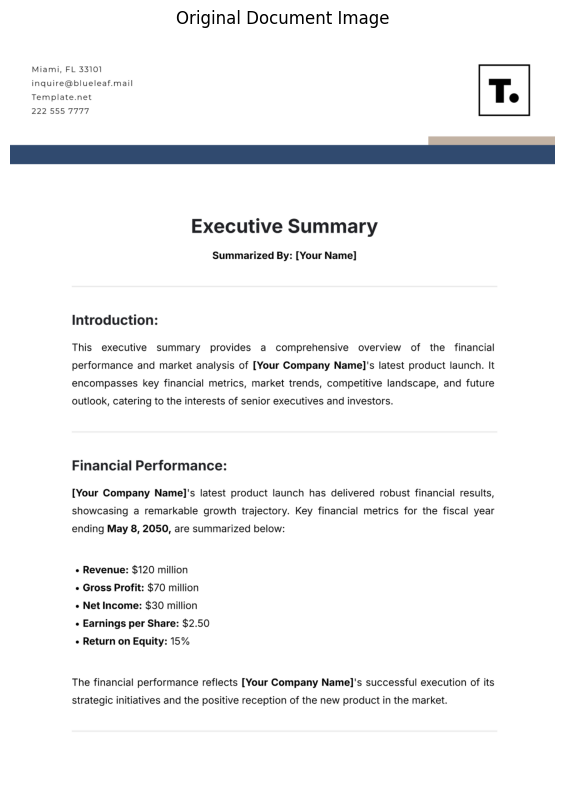

In [7]:
# Provide the path to the document image
image_path = "sample_docs/sample1.png"

# Read image using OpenCV
image = cv2.imread(image_path)

# Convert BGR to RGB for display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the image
plt.figure(figsize=(8, 10))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Original Document Image")
plt.show()


In [8]:
# ## Image Preprocessing

# Printed documents often contain noise, shadows, or uneven lighting.
# Preprocessing improves text isolation before analysis.

# Steps applied:
# 1. Convert image to grayscale
# 2. Apply Gaussian blur to reduce noise
# 3. Apply adaptive thresholding to isolate text regions


Image Preprocessing

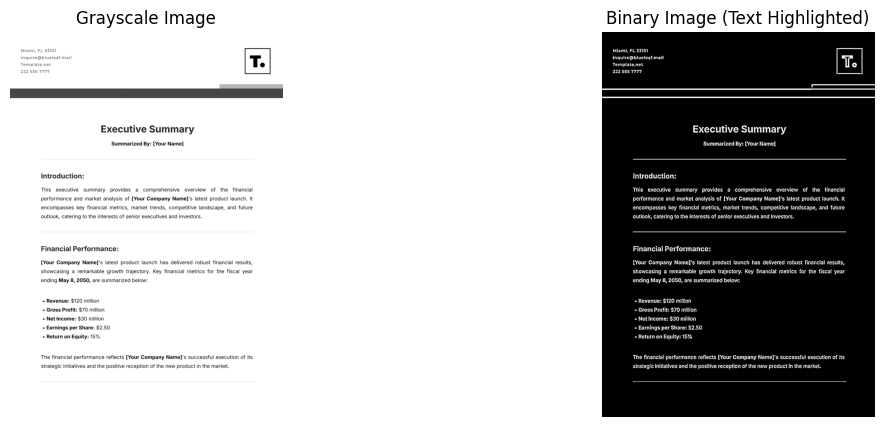

In [9]:
def preprocess_image(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    binary = cv2.adaptiveThreshold(
        blurred,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        15,
        4
    )
    return gray, binary


gray, binary = preprocess_image(image)

# Display preprocessing results
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(binary, cmap="gray")
plt.title("Binary Image (Text Highlighted)")
plt.axis("off")

plt.show()


In [10]:
# ## Skew Detection

# Skew refers to the tilt of text lines in a document.
# It commonly occurs during scanning or camera capture.

# Approach:
# - Detect contours corresponding to text regions
# - Fit a minimum-area rectangle to each contour
# - Extract orientation angles
# - Use the **median angle** to reduce noise


Skew Detection Logic

In [11]:
def detect_skew(gray_image):
    # Edge detection
    edges = cv2.Canny(gray_image, 50, 150, apertureSize=3)

    # Hough Line Transform
    lines = cv2.HoughLines(edges, 1, np.pi / 180, 200)

    if lines is None:
        return 0.0, "OK"

    angles = []

    for line in lines:
        rho, theta = line[0]

        # Convert to degrees relative to horizontal
        angle = (theta - np.pi / 2) * 180 / np.pi

        # Keep only near-horizontal lines (text baselines)
        if -30 < angle < 30:
            angles.append(angle)

    if not angles:
        return 0.0, "OK"

    median_angle = float(np.median(angles))
    abs_angle = abs(median_angle)

    if abs_angle <= 1:
        severity = "OK"
    elif abs_angle <= 3:
        severity = "Warning"
    else:
        severity = "Critical"

    return round(median_angle, 2), severity
skew_angle, skew_severity = detect_skew(gray)
skew_angle,skew_severity

(0.0, 'OK')

In [12]:
# ## Skew Visualization

# To visually validate skew detection, a reference line is drawn at the
# estimated skew angle across the document.


Skew Visualization

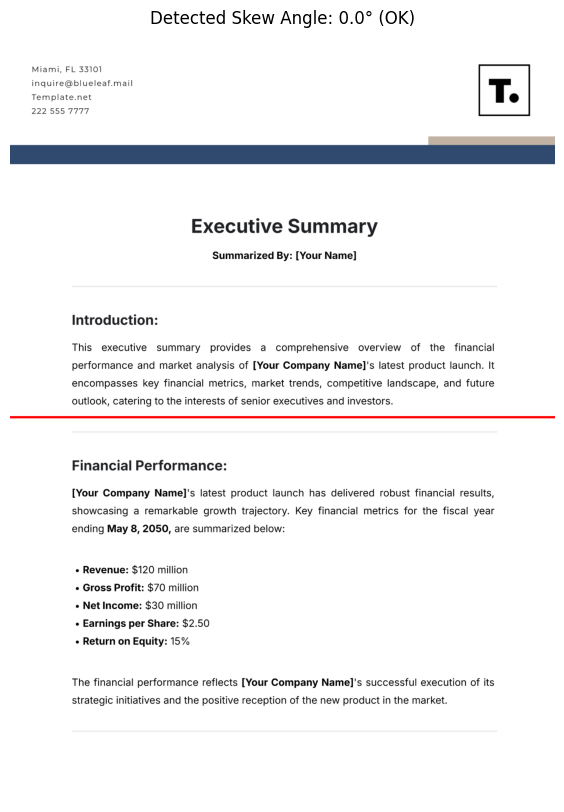

In [13]:
def draw_skew_line(image, angle):
    img = image.copy()
    h, w = img.shape[:2]
    center = (w // 2, h // 2)

    length = max(w, h)
    rad = np.deg2rad(angle)

    x1 = int(center[0] - length * np.cos(rad))
    y1 = int(center[1] + length * np.sin(rad))
    x2 = int(center[0] + length * np.cos(rad))
    y2 = int(center[1] - length * np.sin(rad))

    cv2.line(img, (x1, y1), (x2, y2), (255, 0, 0), 3)
    return img

annotated = draw_skew_line(image_rgb, skew_angle)

plt.figure(figsize=(8, 10))
plt.imshow(annotated)
plt.axis("off")
plt.title(f"Detected Skew Angle: {skew_angle}° ({skew_severity})")
plt.show()


In [14]:
# ## Skew Analysis Summary

# - **Detected Skew Angle:** {:.2f}°
# - **Severity Level:** {}

# ### Interpretation:
# - 0–2° → Acceptable
# - 2–5° → Warning (minor misalignment)
# - >5° → Critical (likely OCR errors)

# ### Limitations:
# - Works best for printed text
# - Highly decorative fonts may affect accuracy
# ```.format(skew_angle, skew_severity)


Font Size Consistency

In [15]:
# ## Font Size Consistency Analysis

# In a well-formatted printed document, body text usually has a **consistent font size**.
# Large variations in text height may indicate:

# - formatting issues
# - scanning distortions
# - mixed content errors
# - poor print quality

# This section analyzes **font size consistency** using OCR bounding boxes,
# without relying on language understanding.


In [16]:
# !pip install pytesseract


In [17]:
import pytesseract
from pytesseract import Output


In [18]:
# ## Extracting Text Bounding Boxes

# Instead of reading text content, we extract **bounding box dimensions**
# for each detected word.

# The height of each bounding box approximates the font size.


Extract Bounding Box Heights

In [19]:
import pytesseract
pytesseract.pytesseract.tesseract_cmd = r"C:\Users\mujam\OneDrive\Documents\Luminar\Machine_Learning\Deep_Learning_Projects\read_text\DL_Project\DL Project\OCR\Tesseract-OCR\tesseract.exe"


In [20]:
def extract_font_heights(image):
    data = pytesseract.image_to_data(
        image,
        output_type=Output.DICT
    )

    heights = []

    for i in range(len(data["text"])):
        text = data["text"][i].strip()
        h = data["height"][i]

        # Filter out noise
        if text != "" and h > 10:
            heights.append(h)

    return heights


font_heights = extract_font_heights(image)
len(font_heights)

132

In [21]:
# ## Font Size Statistics

# We compute basic statistics on detected text heights:

# - Mean font height
# - Variance of font height

# Higher variance indicates **inconsistent font sizing**.


Compute Font Size Metrics

In [22]:
def analyze_font_consistency(heights):
    if len(heights) < 5:
        return 0, "Insufficient Data"

    variance = np.var(heights)

    if variance < 10:
        severity = "Consistent"
    elif variance < 25:
        severity = "Moderate Variation"
    else:
        severity = "Inconsistent"

    return round(variance, 2), severity


font_variance, font_severity = analyze_font_consistency(font_heights)
font_variance, font_severity


(np.float64(11.97), 'Moderate Variation')

In [23]:
# ## Font Size Distribution Visualization

# A histogram helps visualize how font sizes are distributed across the document.


Font Size Histogram

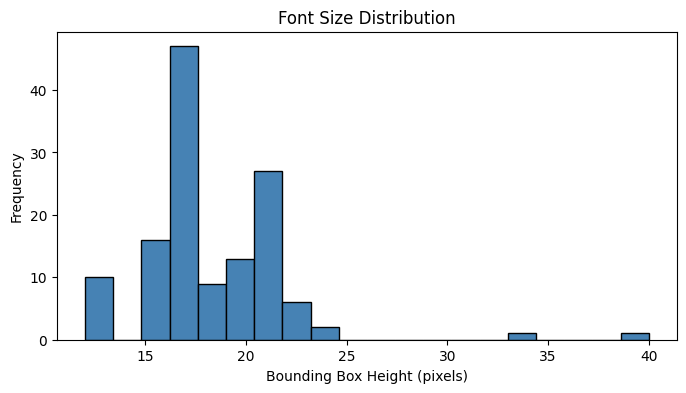

In [24]:
plt.figure(figsize=(8, 4))
plt.hist(font_heights, bins=20, color="steelblue", edgecolor="black")
plt.xlabel("Bounding Box Height (pixels)")
plt.ylabel("Frequency")
plt.title("Font Size Distribution")
plt.show()


In [25]:
# ## Font Size Consistency Summary

# - **Font Size Variance:** {:.2f}
# - **Severity Level:** {}

# ### Interpretation:
# - Low variance → consistent formatting
# - High variance → mixed or distorted font sizes

# ### Limitations:
# - Headings naturally increase variance
# - Decorative fonts may affect accuracy
# ```.format(font_variance, font_severity)


Contrast / Faded Text Detection

In [26]:
# ## Text Contrast and Faded Print Detection

# Good printed documents have **high contrast** between text and background.
# Low contrast may occur due to:

# - faded printing
# - poor scanning
# - low ink quality
# - uneven lighting

# This section measures **local contrast** in text regions to assess readability.


In [27]:
# ### Contrast Measurement Strategy
# # 
# 1. Use OCR to locate text bounding boxes
# 2. Extract grayscale pixel values inside each box
# 3. Compute **standard deviation** of pixel intensities

# Higher standard deviation → higher contrast  
# Lower standard deviation → faded or unclear text


In [28]:
def extract_text_contrast(gray_image, rgb_image):
    data = pytesseract.image_to_data(
        rgb_image,
        output_type=Output.DICT
    )

    contrasts = []

    for i in range(len(data["text"])):
        text = data["text"][i].strip()
        x = data["left"][i]
        y = data["top"][i]
        w = data["width"][i]
        h = data["height"][i]

        if text == "" or w < 10 or h < 10:
            continue

        roi = gray_image[y:y+h, x:x+w]
        if roi.size == 0:
            continue

        _, binary = cv2.threshold(
            roi, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )

        text_pixels = roi[binary == 0]
        bg_pixels   = roi[binary == 255]

        if len(text_pixels) < 10 or len(bg_pixels) < 10:
            continue

        contrast = abs(
            np.mean(text_pixels) - np.mean(bg_pixels)
        )

        contrasts.append(contrast)

    return contrasts

In [29]:
# ## Contrast Score Evaluation

# We compute the **mean contrast score** across all detected text regions.

# Thresholds:
# - > 25 → Good contrast
# - 15–25 → Moderate (slightly faded)
# - < 15 → Poor (faded text)


Compute Contrast Metric

In [30]:
def analyze_contrast(contrasts):
    if len(contrasts) < 5:
        return 0.0, "Insufficient Text Data"

    mean_contrast = float(np.mean(contrasts))

    if mean_contrast > 150:
        level = "Excellent Contrast"
    elif mean_contrast > 80:
        level = "Good Contrast"
    elif mean_contrast > 40:
        level = "Moderate Contrast"
    else:
        level = "Poor Contrast"

    return round(mean_contrast, 2), level


In [31]:
contrast_values = extract_text_contrast(gray, image_rgb)
contrast_score, contrast_level = analyze_contrast(contrast_values)

In [32]:
print("Mean Contrast Score: {:.2f}".format(contrast_score))
print("Contrast Level: {}".format(contrast_level))

Mean Contrast Score: 207.79
Contrast Level: Excellent Contrast


In [33]:
# ## Contrast Distribution Visualization

# The histogram below shows how contrast varies across different text regions.
# # 

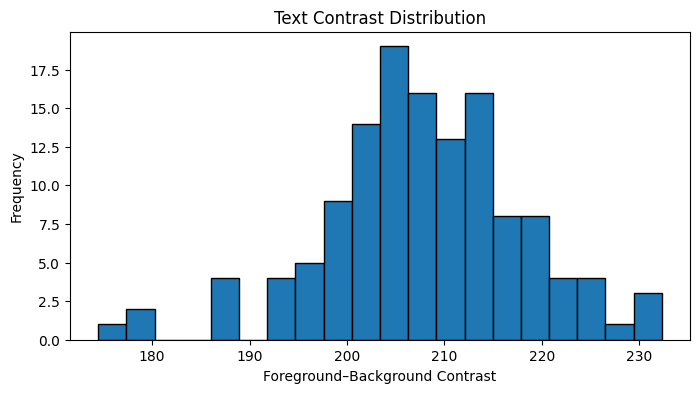

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(contrast_values, bins=20, edgecolor="black")
plt.xlabel("Foreground–Background Contrast")
plt.ylabel("Frequency")
plt.title("Text Contrast Distribution")
plt.show()

In [35]:
# ## Contrast Analysis Summary

# - **Mean Contrast Score:** {:.2f}
# - **Severity Level:** {}

# ### Interpretation:
# - High contrast improves readability and OCR accuracy
# - Low contrast indicates faded or poor-quality printing

# ### Limitations:
# - Shadows may artificially reduce contrast
# - Colored backgrounds can affect measurements
# ```.format(contrast_score, contrast_severity)


In [36]:
# If asked:

# “Why did you choose these metrics?”

# Answer:

# “They represent three independent document quality dimensions: geometry, typography, and visual clarity.”

In [37]:
# ## Line Spacing Irregularity Analysis

# In well-formatted printed documents, the vertical spacing between consecutive
# text lines is usually consistent.

# Irregular line spacing may indicate:
# - formatting errors
# - scanning distortions
# - mixed content layouts
# - poor document structure

# This section analyzes **vertical spacing between text lines** using OCR
# bounding box positions.


In [38]:
# ### Line Spacing Measurement Strategy

# 1. Use OCR bounding boxes to get text positions
# 2. Group text boxes by approximate horizontal alignment (lines)
# 3. Compute vertical distances between consecutive lines
# 4. Measure variance of these distances

# Higher variance → irregular spacing
# Lower variance → consistent layout


Extract Line Y-Positions

In [39]:
def extract_line_positions(image):
    data = pytesseract.image_to_data(
        image,
        output_type=Output.DICT
    )

    lines = {}

    for i in range(len(data["text"])):
        text = data["text"][i].strip()
        y = data["top"][i]
        h = data["height"][i]

        if text != "" and h > 10:
            # group by approximate y-position
            key = y // 10
            if key not in lines:
                lines[key] = []
            lines[key].append(y)

    # average y position per line
    line_positions = sorted(
        [int(np.mean(v)) for v in lines.values()]
    )

    return line_positions


line_positions = extract_line_positions(image)
line_positions[:11], len(line_positions)


([75, 106, 136, 168, 410, 483, 622, 685, 690, 725, 765], 24)

In [40]:
def analyze_line_spacing(line_positions):
    if len(line_positions) < 3:
        return 0, "Insufficient Data", []

    spacings = np.diff(line_positions)
    variance = np.var(spacings)

    if variance < 15:
        severity = "Consistent"
    elif variance < 30:
        severity = "Uneven"
    else:
        severity = "Disorganized"

    return round(variance, 2), severity, spacings


In [41]:
line_positions = extract_line_positions(image)


In [42]:
line_variance, line_severity, spacings = analyze_line_spacing(line_positions)


In [43]:
# ## Line Spacing Distribution Visualization

# The histogram below shows the distribution of vertical spacing
# between consecutive text lines.


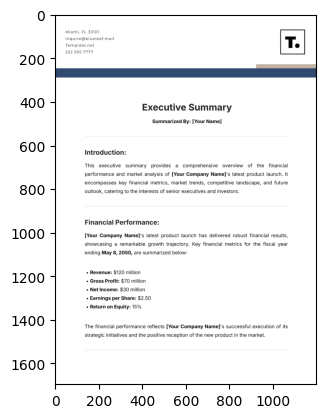

In [44]:
plt.imshow(image_rgb)


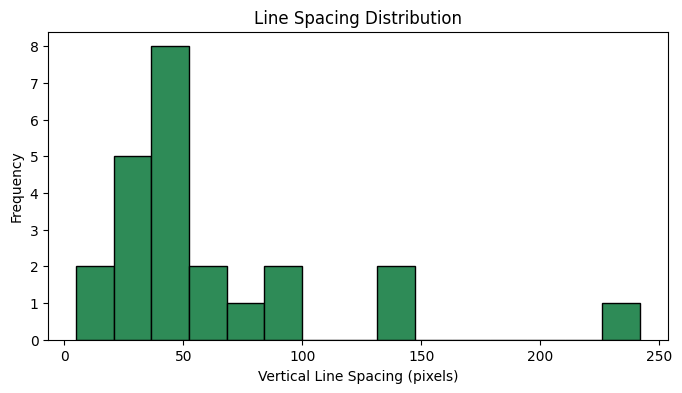

In [45]:
plt.figure(figsize=(8, 4))
plt.hist(spacings, bins=15, color="seagreen", edgecolor="black")
plt.xlabel("Vertical Line Spacing (pixels)")
plt.ylabel("Frequency")
plt.title("Line Spacing Distribution")
plt.show()


In [46]:
# ## Line Spacing Analysis Summary

# - **Line Spacing Variance:** {:.2f}
# - **Severity Level:** {}

# ### Interpretation:
# - Low variance → uniform layout
# - High variance → irregular or poorly formatted document

# ### Limitations:
# - Paragraph breaks increase variance naturally
# - Multi-column layouts may affect grouping
# ```.format(line_variance, line_severity)


In [47]:
# !pip install pandas

In [48]:
print(
    "skew_angle:", 'skew_angle' in globals(),
    "font_variance:", 'font_variance' in globals(),
    "contrast_score:", 'contrast_score' in globals(),
    "line_variance:", 'line_variance' in globals()
)


skew_angle: True font_variance: True contrast_score: True line_variance: True


In [49]:
import pandas as pd

summary_data = {
    "Metric": [
        "Skew Angle (degrees)",
        "Font Size Variance",
        "Text Contrast Score",
        "Line Spacing Variance"
    ],
    "Value": [
        round(skew_angle, 2),
        round(font_variance, 2),
        round(contrast_score, 2),
        round(line_variance, 2)
    ],
    "Severity / Interpretation": [
        skew_severity,
        font_severity,
        contrast_level,
        line_severity
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df


,Metric,Value,Severity / Interpretation
0,Skew Angle (degrees),0.00,OK
1,Font Size Variance,11.97,Moderate Variation
2,Text Contrast Score,207.79,Excellent Contrast
3,Line Spacing Variance,2636.05,Disorganized


In [50]:
# Export summary table

summary_df.to_csv("visual_error_report.csv", index=False)

print("Reports saved:")
print("✔ visual_error_report.csv")
print("✔ visual_error_report.xlsx")


Reports saved:
✔ visual_error_report.csv
✔ visual_error_report.xlsx
